In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import folium
from folium.plugins import HeatMap

In [4]:
events = pd.read_csv("events.csv", encoding="ISO-8859-1", low_memory=False)
injury = pd.read_csv("injury.csv", encoding="ISO-8859-1", low_memory=False)
aircraft = pd.read_csv("aircraft.csv", encoding="ISO-8859-1", low_memory=False)
engines = pd.read_csv("engines.csv", encoding="ISO-8859-1", low_memory=False)

print(events.shape, injury.shape, aircraft.shape, engines.shape)

(30212, 73) (173347, 7) (30726, 93) (27723, 17)


In [5]:
# Drop duplicate columns BEFORE merging

injury = injury.loc[:, ~injury.columns.duplicated()]
aircraft = aircraft.loc[:, ~aircraft.columns.duplicated()]
engines = engines.loc[:, ~engines.columns.duplicated()]

# Also remove unnecessary system columns
cols_to_drop = ["lchg_date", "lchg_userid"]

injury = injury.drop(columns=cols_to_drop, errors="ignore")
aircraft = aircraft.drop(columns=cols_to_drop, errors="ignore")
engines = engines.drop(columns=cols_to_drop, errors="ignore")

# Now merge
df = events.merge(injury, on="ev_id", how="left")
df = df.merge(aircraft, on="ev_id", how="left")
df = df.merge(engines, on="ev_id", how="left")

print(df.shape)
df.head()

(212282, 181)


,ev_id,ntsb_no_x,ev_type,ev_date,ev_dow,ev_time,ev_tmzn,ev_city,ev_state,ev_country,...,eng_model,power_units,hp_or_lbs,carb_fuel_injection,propeller_type,propeller_make,propeller_model,eng_time_total,eng_time_last_insp,eng_time_overhaul
0,20080211X00175,DFW08RA039,ACC,10/01/08 00:00,Th,1907.0,UTC,Pitt Meadows,NaN,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20080211X00175,DFW08RA039,ACC,10/01/08 00:00,Th,1907.0,UTC,Pitt Meadows,NaN,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20080211X00175,DFW08RA039,ACC,10/01/08 00:00,Th,1907.0,UTC,Pitt Meadows,NaN,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20080211X00175,DFW08RA039,ACC,10/01/08 00:00,Th,1907.0,UTC,Pitt Meadows,NaN,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20080211X00175,DFW08RA039,ACC,10/01/08 00:00,Th,1907.0,UTC,Pitt Meadows,NaN,CA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print(df.columns)

Index(['ev_id', 'ntsb_no_x', 'ev_type', 'ev_date', 'ev_dow', 'ev_time',
       'ev_tmzn', 'ev_city', 'ev_state', 'ev_country',
       ...
       'eng_model', 'power_units', 'hp_or_lbs', 'carb_fuel_injection',
       'propeller_type', 'propeller_make', 'propeller_model', 'eng_time_total',
       'eng_time_last_insp', 'eng_time_overhaul'],
      dtype='object', length=181)


In [7]:
df["severity_score"] = (
    df["inj_tot_f"] * 5 +
    df["inj_tot_s"] * 3 +
    df["inj_tot_m"] * 1
)

In [8]:
df["severity_class"] = 0
df.loc[df["severity_score"] > 10, "severity_class"] = 1

df["severity_class"].value_counts()

severity_class
0    196158
1     16124
Name: count, dtype: int64

In [9]:
# Convert date properly
df["ev_date"] = pd.to_datetime(df["ev_date"], errors="coerce")

# Create event_year column
df["event_year"] = df["ev_date"].dt.year

C:\Users\asus\AppData\Local\Temp\ipykernel_11800\2020883117.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ev_date"] = pd.to_datetime(df["ev_date"], errors="coerce")


In [10]:
# Convert date properly
df["ev_date"] = pd.to_datetime(df["ev_date"], errors="coerce")

# Create event_year column
df["event_year"] = df["ev_date"].dt.year

In [11]:
print("event_year" in df.columns)

True


In [12]:
print(df.columns)

Index(['ev_id', 'ntsb_no_x', 'ev_type', 'ev_date', 'ev_dow', 'ev_time',
       'ev_tmzn', 'ev_city', 'ev_state', 'ev_country',
       ...
       'carb_fuel_injection', 'propeller_type', 'propeller_make',
       'propeller_model', 'eng_time_total', 'eng_time_last_insp',
       'eng_time_overhaul', 'severity_score', 'severity_class', 'event_year'],
      dtype='object', length=184)


In [13]:
important_cols = [
    "event_year",
    "wx_temp",
    "acft_year",
    "num_eng",
    "eng_time_total",
    "inj_tot_f",
    "inj_tot_s",
    "inj_tot_m",
    "inj_tot_n",
    "severity_score",
    "severity_class"
]

df_ml = df[important_cols].copy()

print(df_ml.shape)
df_ml.head()

(212282, 11)


,event_year,wx_temp,acft_year,num_eng,eng_time_total,inj_tot_f,inj_tot_s,inj_tot_m,inj_tot_n,severity_score,severity_class
0,2008,0.0,NaN,NaN,NaN,0,0,0,2,0,0
1,2008,0.0,NaN,NaN,NaN,0,0,0,2,0,0
2,2008,0.0,NaN,NaN,NaN,0,0,0,2,0,0
3,2008,0.0,NaN,NaN,NaN,0,0,0,2,0,0
4,2008,0.0,NaN,NaN,NaN,0,0,0,2,0,0


In [14]:
df_ml = df_ml.copy()

df_ml.loc[:, "wx_temp"] = df_ml["wx_temp"].fillna(df_ml["wx_temp"].median())
df_ml.loc[:, "acft_year"] = df_ml["acft_year"].fillna(0)
df_ml.loc[:, "eng_time_total"] = df_ml["eng_time_total"].fillna(0)
df_ml.loc[:, "num_eng"] = df_ml["num_eng"].fillna(1)

In [15]:
df_ml.fillna(0, inplace=True)

In [16]:
df_ml["aircraft_age"] = df_ml["event_year"] - df_ml["acft_year"]

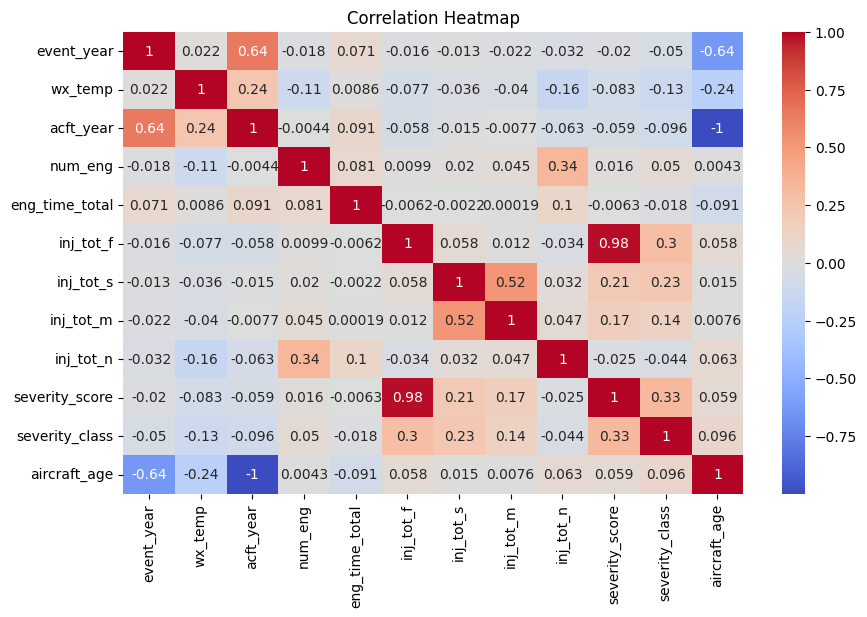

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df_ml.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

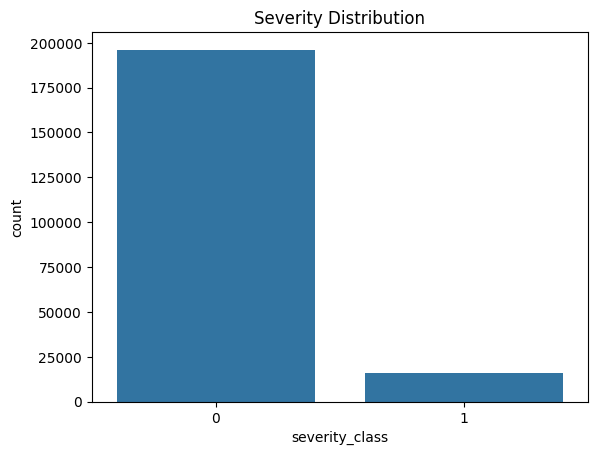

In [18]:
sns.countplot(x="severity_class", data=df_ml)
plt.title("Severity Distribution")
plt.show()

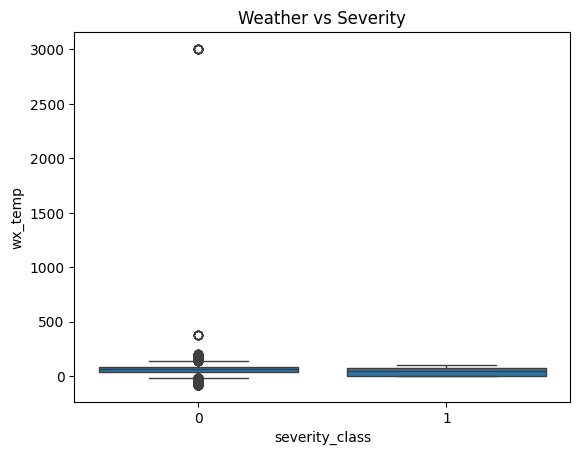

In [19]:
sns.boxplot(x="severity_class", y="wx_temp", data=df_ml)
plt.title("Weather vs Severity")
plt.show()

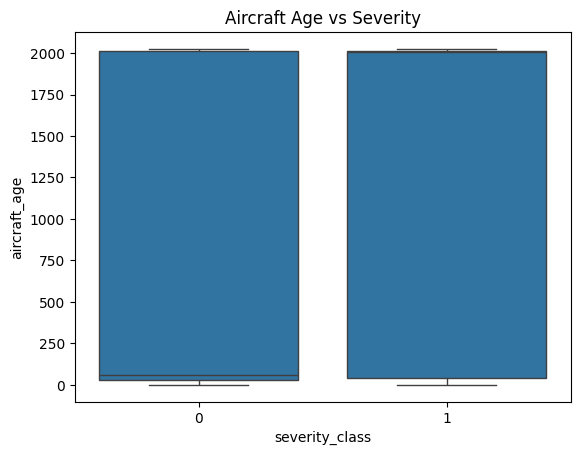

In [20]:
sns.boxplot(x="severity_class", y="aircraft_age", data=df_ml)
plt.title("Aircraft Age vs Severity")
plt.show()

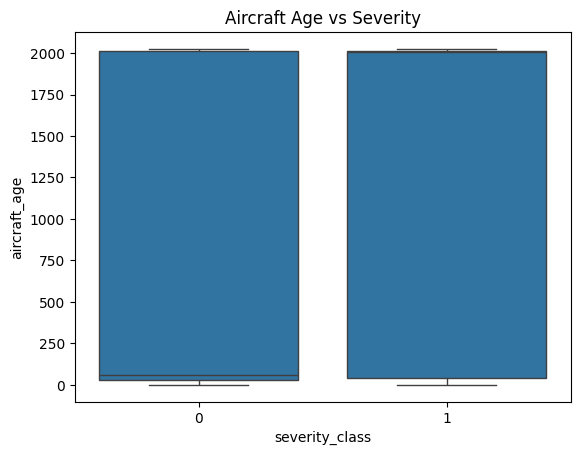

In [21]:
sns.boxplot(x="severity_class", y="aircraft_age", data=df_ml)
plt.title("Aircraft Age vs Severity")
plt.show()

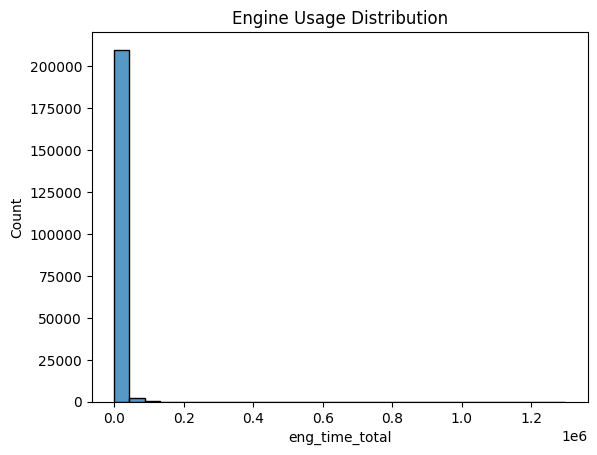

In [22]:
sns.histplot(df_ml["eng_time_total"], bins=30)
plt.title("Engine Usage Distribution")
plt.show()

In [23]:
X = df_ml.drop("severity_class", axis=1)
y = df_ml["severity_class"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


In [27]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [28]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


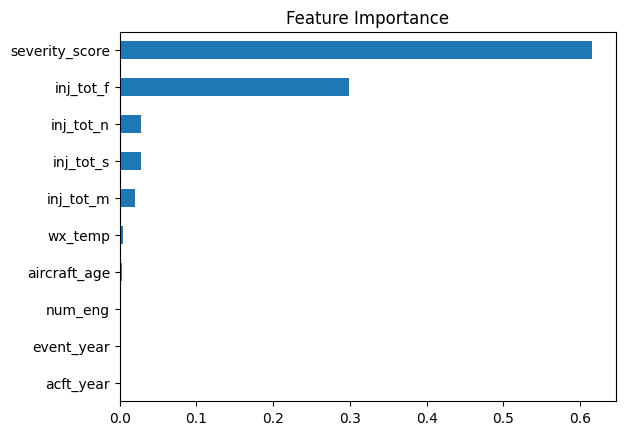

In [29]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().tail(10).plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Logistic
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Accuracy: 1.0
Random Forest Accuracy: 1.0


<Axes: >

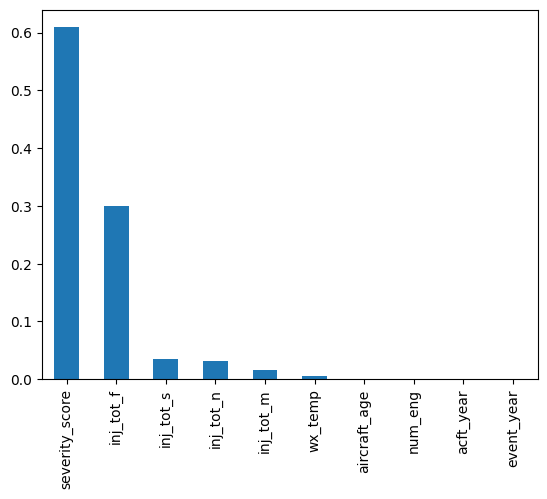

In [31]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind="bar")

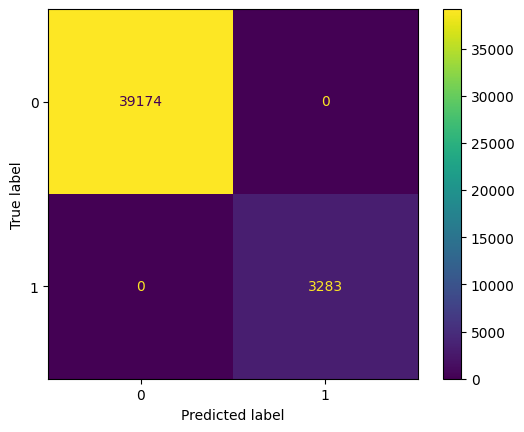

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm).plot()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39174
           1       1.00      1.00      1.00      3283

    accuracy                           1.00     42457
   macro avg       1.00      1.00      1.00     42457
weighted avg       1.00      1.00      1.00     42457



In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

print("Gradient Boost Accuracy:", gb.score(X_test, y_test))

Gradient Boost Accuracy: 1.0


In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 1.0


In [36]:
# Convert coordinates to decimal

def convert_coord(coord):
    try:
        if pd.isnull(coord):
            return None
        
        coord = str(coord)
        
        # Example: 039402N → 39°40'2"N
        degree = int(coord[:3])
        minute = int(coord[3:5])
        second = int(coord[5:7])
        direction = coord[-1]
        
        decimal = degree + minute/60 + second/3600
        
        if direction in ["S", "W"]:
            decimal = -decimal
            
        return decimal
    
    except:
        return None


# Apply conversion
df["lat_decimal"] = df["latitude"].apply(convert_coord)
df["lon_decimal"] = df["longitude"].apply(convert_coord)

print("Coordinates converted ✅")

Coordinates converted ✅


In [37]:
print(df[["lat_decimal", "lon_decimal"]].head())

   lat_decimal  lon_decimal
0          NaN   -12.403333
1          NaN   -12.403333
2          NaN   -12.403333
3          NaN   -12.403333
4          NaN   -12.403333


In [38]:
print(df["latitude"].head(10))
print(df["longitude"].head(10))

0    049130N
1    049130N
2    049130N
3    049130N
4    049130N
5    381326N
6    381326N
7    381326N
8    381326N
9    381326N
Name: latitude, dtype: object
0    0122412W
1    0122412W
2    0122412W
3    0122412W
4    0122412W
5    1222659W
6    1222659W
7    1222659W
8    1222659W
9    1222659W
Name: longitude, dtype: object


In [39]:
def convert_coord(coord):
    try:
        if pd.isnull(coord):
            return None
        
        coord = str(coord)

        direction = coord[-1]
        coord = coord[:-1]

        # Latitude (2-digit degree) vs Longitude (3-digit degree)
        if len(coord) == 6:  # latitude
            degree = int(coord[:2])
            minute = int(coord[2:4])
            second = int(coord[4:6])
        elif len(coord) == 7:  # longitude
            degree = int(coord[:3])
            minute = int(coord[3:5])
            second = int(coord[5:7])
        else:
            return None

        decimal = degree + minute/60 + second/3600

        if direction in ["S", "W"]:
            decimal = -decimal

        return decimal

    except:
        return None

In [40]:
df["lat_decimal"] = df["latitude"].apply(convert_coord)
df["lon_decimal"] = df["longitude"].apply(convert_coord)

In [41]:
print(df[["lat_decimal", "lon_decimal"]].head())

   lat_decimal  lon_decimal
0        5.525   -12.403333
1        5.525   -12.403333
2        5.525   -12.403333
3        5.525   -12.403333
4        5.525   -12.403333


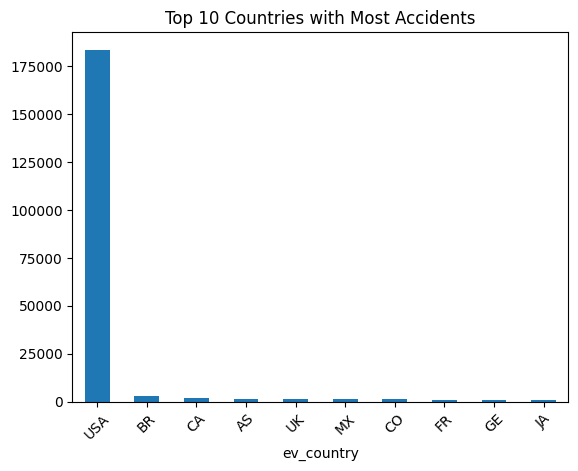

In [42]:
import matplotlib.pyplot as plt

df["ev_country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries with Most Accidents")
plt.xticks(rotation=45)
plt.show()

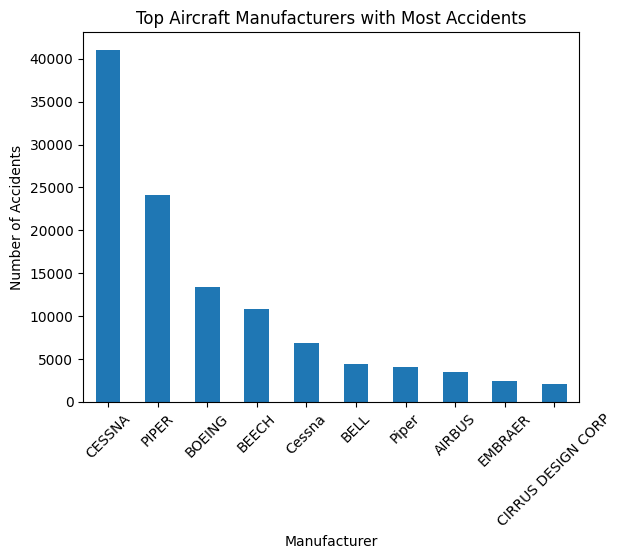

In [43]:
top_makes = df["acft_make"].value_counts().head(10)

top_makes.plot(kind="bar")
plt.title("Top Aircraft Manufacturers with Most Accidents")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

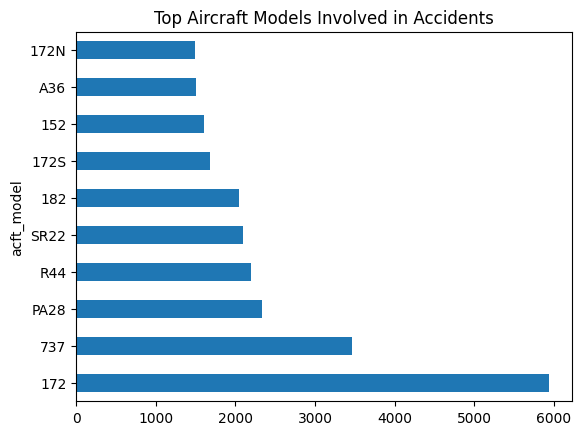

In [44]:
df["acft_model"].value_counts().head(10).plot(kind="barh")
plt.title("Top Aircraft Models Involved in Accidents")
plt.show()

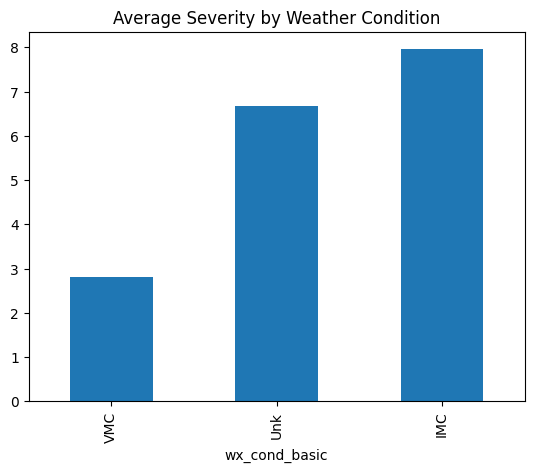

In [45]:
df.groupby("wx_cond_basic")["severity_score"].mean().sort_values().plot(kind="bar")
plt.title("Average Severity by Weather Condition")
plt.show()

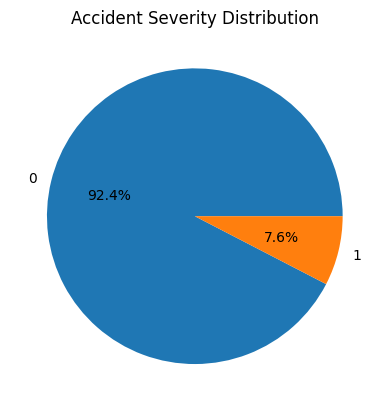

In [46]:
df["severity_class"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Accident Severity Distribution")
plt.ylabel("")
plt.show()

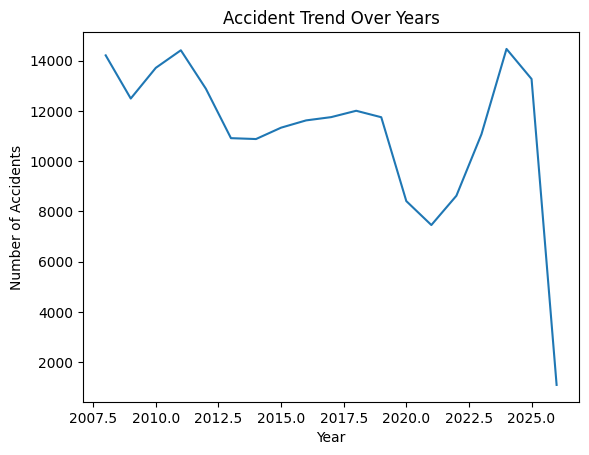

In [47]:
df.groupby("event_year").size().plot()
plt.title("Accident Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

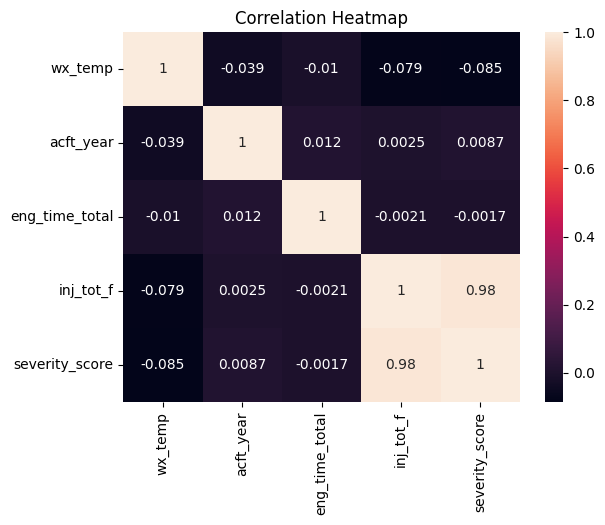

In [48]:
import seaborn as sns

corr = df[[
    "wx_temp",
    "acft_year",
    "eng_time_total",
    "inj_tot_f",
    "severity_score"
]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

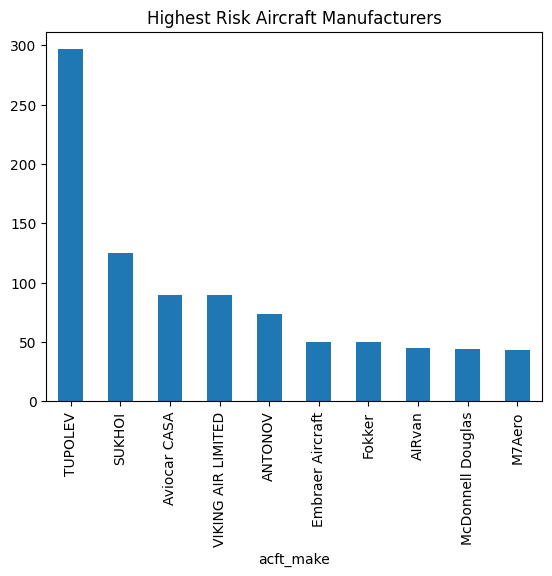

In [49]:
risk = df.groupby("acft_make")["severity_score"].mean().sort_values(ascending=False).head(10)

risk.plot(kind="bar")
plt.title("Highest Risk Aircraft Manufacturers")
plt.show()

In [50]:
print(df["severity_class"].value_counts())

severity_class
0    196158
1     16124
Name: count, dtype: int64


In [51]:
def predict_accident(input_data):
    input_df = pd.DataFrame([input_data])

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    result = "Severe" if prediction == 1 else "Non-Severe"

    return result, probability

In [52]:
def explain_factors(input_data):
    factors = []

    if input_data["wx_temp"] < 0:
        factors.append("Low temperature (icing risk)")

    if input_data["eng_time_total"] > 5000:
        factors.append("High engine usage")

    if input_data["num_eng"] == 1:
        factors.append("Single engine aircraft (higher risk)")

    return factors

In [53]:
def accident_analysis_system(data_input):
    severity, prob = predict_accident(data_input)
    insights = explain_factors(data_input)

    print("\n🔍 ACCIDENT ANALYSIS RESULT")
    print("Severity:", severity)
    print("Probability:", round(prob, 2))

    print("\n⚠️ Key Risk Factors:")
    for i in insights:
        print("-", i)

In [54]:
model_columns = X.columns

In [55]:
def predict_accident(input_data):
    input_df = pd.DataFrame([input_data])

    # Add missing columns
    for col in model_columns:
        if col not in input_df:
            input_df[col] = 0

    # Ensure same column order
    input_df = input_df[model_columns]

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    result = "Severe" if prediction == 1 else "Non-Severe"

    return result, probability

In [56]:
sample_input = {
    "event_year": 2015,
    "wx_temp": -5,
    "acft_year": 2000,
    "num_eng": 1,
    "eng_time_total": 5000,
    "inj_tot_f": 0,
    "inj_tot_s": 1,
    "inj_tot_m": 0,
    "inj_tot_n": 2,
    "severity_score": 8
}

In [57]:
sample_input["aircraft_age"] = sample_input["event_year"] - sample_input["acft_year"]

In [58]:
sample_input = {
    "event_year": 2015,
    "wx_temp": -5,
    "acft_year": 1998,
    "num_eng": 1,
    "eng_time_total": 6000,
    "inj_tot_f": 1,
    "inj_tot_s": 2,
    "inj_tot_m": 0,
    "inj_tot_n": 0,
    "severity_score": 8
}

# Add derived feature
sample_input["aircraft_age"] = sample_input["event_year"] - sample_input["acft_year"]

accident_analysis_system(sample_input)


🔍 ACCIDENT ANALYSIS RESULT
Severity: Non-Severe
Probability: 0.08

⚠️ Key Risk Factors:
- Low temperature (icing risk)
- High engine usage
- Single engine aircraft (higher risk)


In [59]:
sample_input = {
    "event_year": 2010,
    "wx_temp": -20,
    "acft_year": 1980,
    "num_eng": 1,
    "eng_time_total": 9000,
    "inj_tot_f": 3,
    "inj_tot_s": 2,
    "inj_tot_m": 1,
    "inj_tot_n": 0,
    "severity_score": 10
}

sample_input["aircraft_age"] = sample_input["event_year"] - sample_input["acft_year"]

accident_analysis_system(sample_input)


🔍 ACCIDENT ANALYSIS RESULT
Severity: Non-Severe
Probability: 0.43

⚠️ Key Risk Factors:
- Low temperature (icing risk)
- High engine usage
- Single engine aircraft (higher risk)


In [60]:
df[["lat_decimal", "lon_decimal"]].dropna().shape

(197274, 2)

In [61]:
severe_df = df[df["severity_score"] >= 7]

map_df2 = severe_df[["lat_decimal", "lon_decimal"]].dropna()

if len(map_df2) > 0:
    map_df2 = map_df2.sample(min(3000, len(map_df2)))

    m2 = folium.Map(location=[39.5, -98.35], zoom_start=4)

    HeatMap(map_df2.values, radius=10,
            gradient={0.4: 'blue', 0.65: 'yellow', 1: 'red'}).add_to(m2)

    m2
else:
    print("No severe accident data")

In [62]:
map_df = df[["lat_decimal", "lon_decimal"]].dropna().sample(5000)

m = folium.Map(location=[39.5, -98.35], zoom_start=4)

HeatMap(map_df.values).add_to(m)

m

In [63]:
import os

print(os.listdir())

['aircraft.csv', 'app.py', 'aviation_project.ipynb', 'columns.pkl', 'engines.csv', 'events.csv', 'injury.csv', 'model.pkl', 'narratives.csv']


In [64]:
import pickle

# save feature columns
pickle.dump(X.columns.tolist(), open("columns.pkl", "wb"))

print("Columns saved!")

Columns saved!


In [66]:
print(df.columns)

Index(['ev_id', 'ntsb_no_x', 'ev_type', 'ev_date', 'ev_dow', 'ev_time',
       'ev_tmzn', 'ev_city', 'ev_state', 'ev_country',
       ...
       'propeller_make', 'propeller_model', 'eng_time_total',
       'eng_time_last_insp', 'eng_time_overhaul', 'severity_score',
       'severity_class', 'event_year', 'lat_decimal', 'lon_decimal'],
      dtype='object', length=186)


In [67]:
print(df[["lat_decimal", "lon_decimal"]].dropna().shape)

(197274, 2)
